<a href="https://colab.research.google.com/github/rally-adty/UNSIA-Data-Sciense-SM-4/blob/main/Pertemuan3_M_Rally_Adityo_240401010212.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install missingno

In [2]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats.mstats import winsorize

import requests

In [3]:
df = pd.read_csv('housing_dirty.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'housing_dirty.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
import os
os.listdir()

['.config', 'sample_data']

In [6]:
df = pd.read_csv('housing_dirty.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'housing_dirty.csv'

In [7]:
df = pd.read_csv('housing_dirty.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'housing_dirty.csv'

In [9]:
df = pd.read_csv('/housing_dirty.csv')

df.head()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            130 non-null    int64  
 1   luas_m2       112 non-null    float64
 2   harga_juta    113 non-null    float64
 3   kota          130 non-null    object 
 4   kamar         120 non-null    float64
 5   tahun_bangun  130 non-null    int64  
 6   kondisi       130 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 7.2+ KB


In [12]:
df.describe()

,id,luas_m2,harga_juta,kamar,tahun_bangun
count,130.000000,112.000000,1.130000e+02,120.000000,130.000000
mean,65.500000,267.627679,8.856325e+05,3.433333,2062.638462
std,37.671829,885.664181,9.407144e+06,1.776283,701.684043
min,1.000000,-50.000000,-5.000000e+02,1.000000,1890.000000
25%,33.250000,87.050000,3.450000e+02,2.000000,1991.250000
50%,65.500000,193.800000,6.550000e+02,4.000000,2002.000000
75%,97.750000,280.675000,9.550000e+02,5.000000,2011.750000
max,130.000000,9500.000000,1.000000e+08,6.000000,9999.000000


In [13]:
df.isnull().sum()

,0
id,0
luas_m2,18
harga_juta,17
kota,0
kamar,10
tahun_bangun,0
kondisi,0


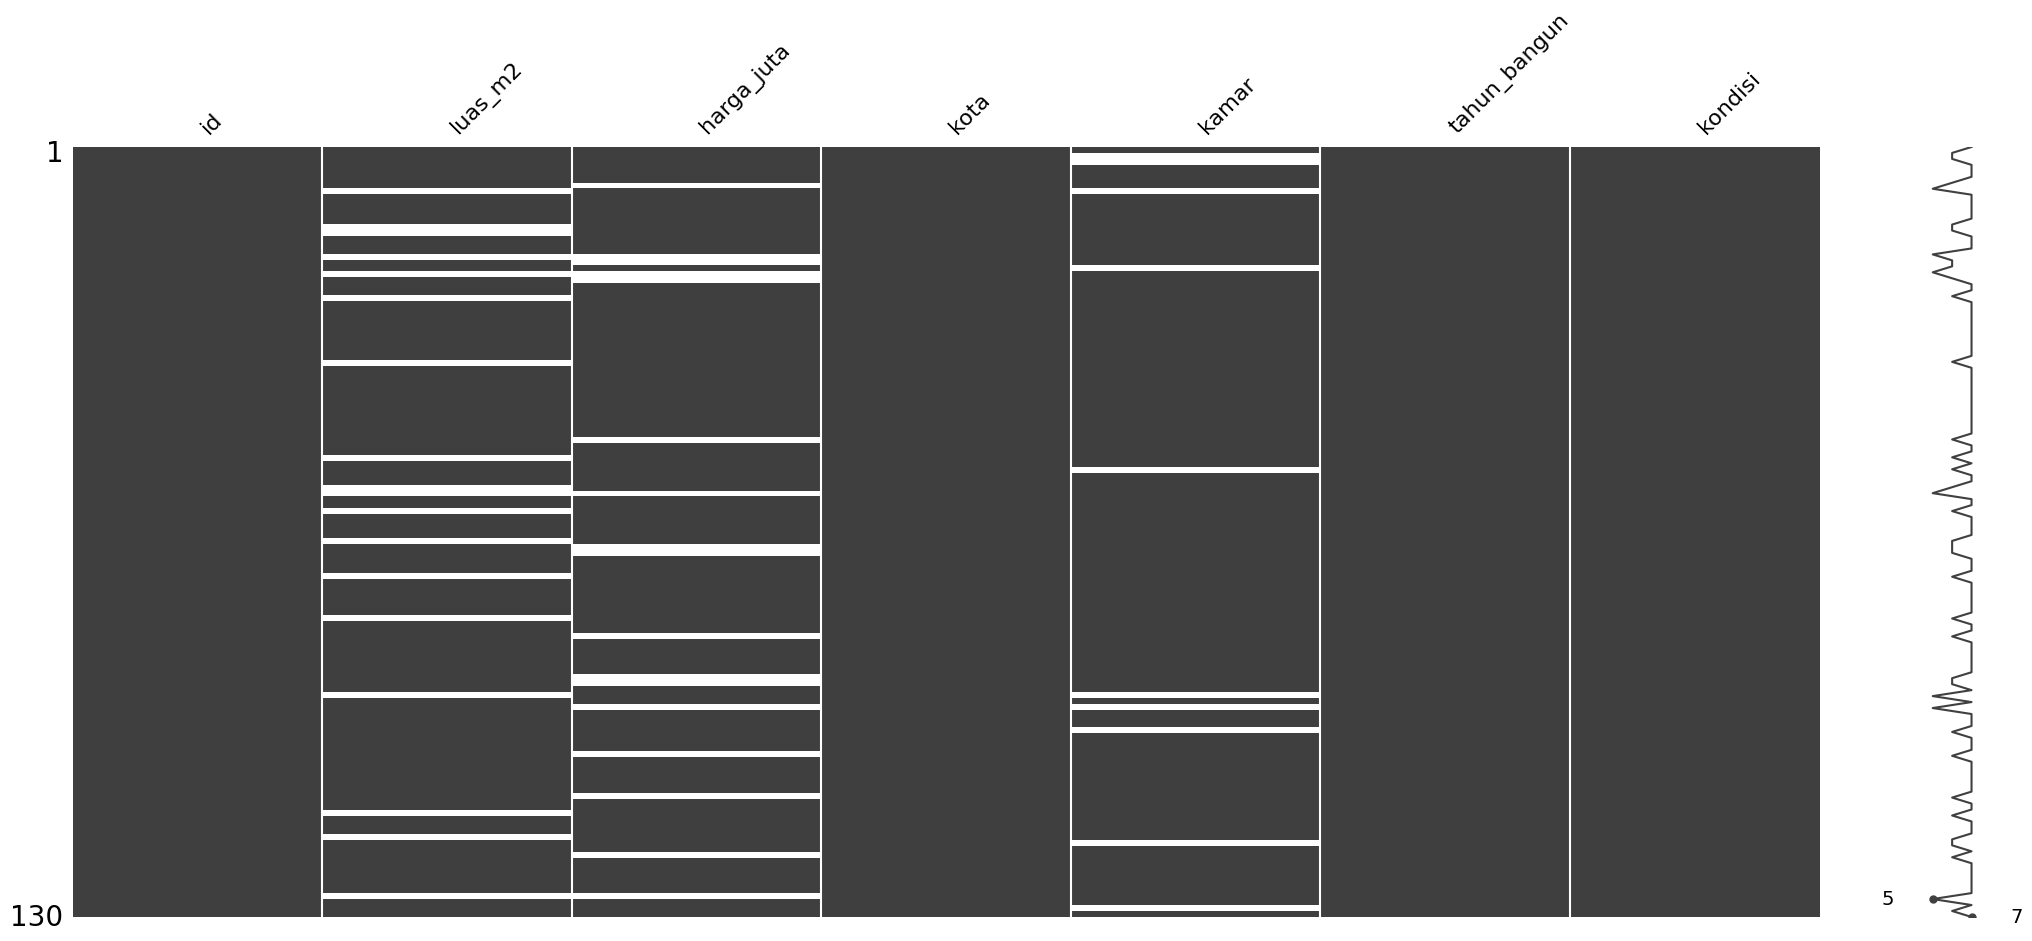

In [14]:
msno.matrix(df)
plt.show()

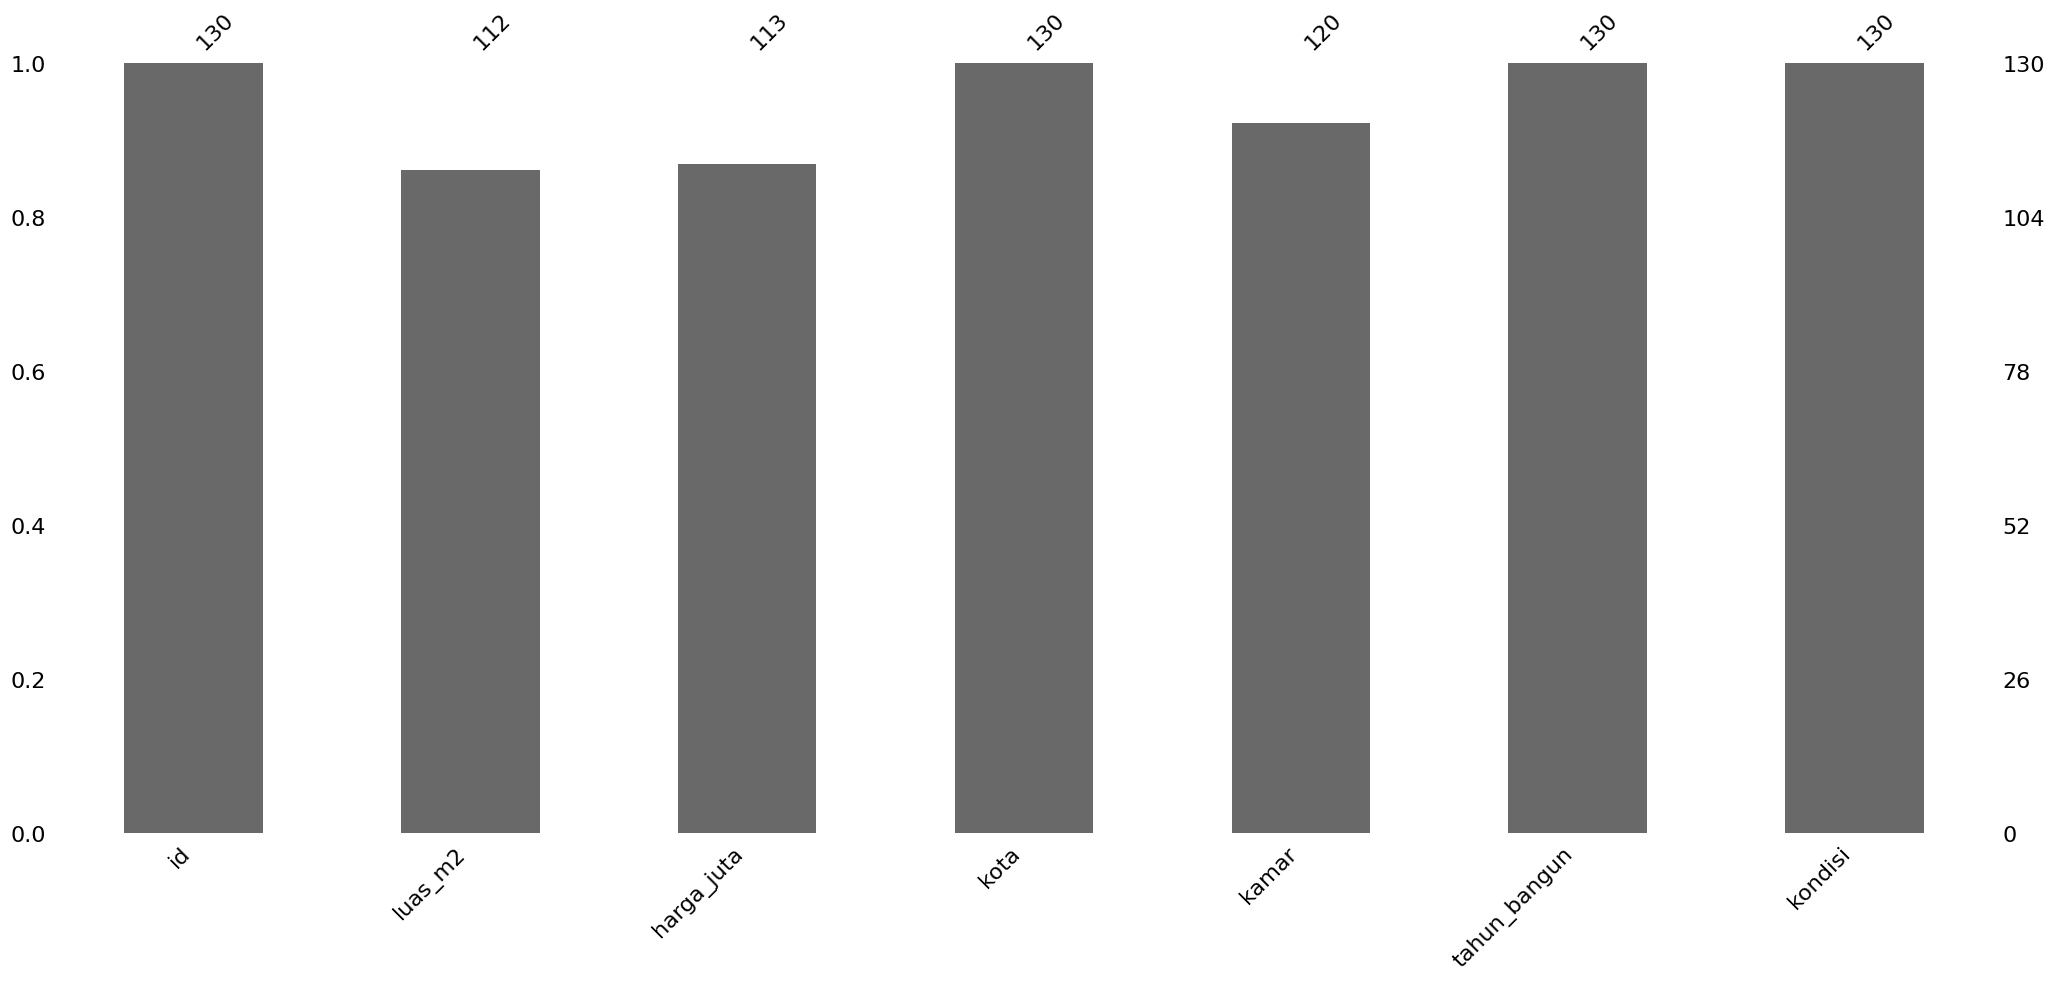

In [15]:
msno.bar(df)
plt.show()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['kota'] = df['kota'].str.strip().str.title()

In [20]:
df['kondisi'] = df['kondisi'].str.strip().str.lower()

In [21]:
df['luas_m2'] = df['luas_m2'].fillna(df['luas_m2'].median())

df['harga_juta'] = df['harga_juta'].fillna(df['harga_juta'].median())

In [22]:
df['kamar'] = df['kamar'].fillna(df['kamar'].mode()[0])

In [23]:
df.isnull().sum()

,0
id,0
luas_m2,0
harga_juta,0
kota,0
kamar,0
tahun_bangun,0
kondisi,0


In [24]:
for col in ['harga_juta', 'luas_m2', 'tahun_bangun']:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

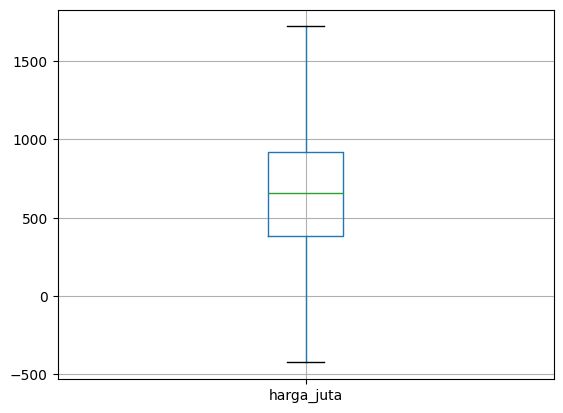

In [25]:
df.boxplot(column=['harga_juta'])
plt.show()

In [26]:
df.isnull().sum().sum()

np.int64(0)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.to_csv('housing_clean.csv', index=False)

In [29]:
from google.colab import files
files.download('housing_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)

In [31]:
print(response.status_code)

200


In [32]:
data = response.json()

df_api = pd.DataFrame(data)

In [33]:
df_api.head()

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


In [34]:
df_api.to_csv('users_api.csv', index=False)

In [35]:
files.download('users_api.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>